# Trabalho de Pós-Graduação: Análise Exploratória e Modelagem Preditiva de F1

**Autores:** Thales Cogo e Lázaro Visotto  
**Professor:** Prof. Marcelo Diaz  
**Disciplina:** Pós-Graduação CDIA (Ciência de Dados e Inteligência Artificial) - Módulo 5  

--- 

Este notebook apresenta um projeto completo focado em **Análise Exploratória de Dados (AED)**, **Feature Engineering** e **Pipeline de Dados** aplicados ao dataset histórico da Fórmula 1. O objetivo final é prever a classificação da corrida do **GP da Hungria de 2026** (Hungaroring) com base na forma dos pilotos, dominância das equipes e retrospecto histórico na pista.

### Melhorias e Ajustes de Engenharia de Dados:
1. **Laplace Smoothing no Histórico da Pista:** Para pilotos estreantes (como Andrea Kimi Antonelli), o modelo suaviza o retrospecto histórico mesclando-o com a forma do campeonato atual ($k=3$).
2. **Suavização de Punições no Grid (Proxy Robusto):** Para evitar propagar punições pontuais por troca de motor sofridas por Lando Norris e Isack Hadjar na Bélgica, o pipeline calcula e utiliza a **posição média de largada do piloto na temporada de 2026** como proxy para a corrida alvo.

In [1]:
# Instalação das dependências necessárias
# Execute esta célula se não possuir os pacotes instalados em seu ambiente Python
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Importação das bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configurações estéticas dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Seção 1: Exploração e Diagnóstico de Dados (EDA)

Nesta seção, realizo o carregamento dos arquivos CSV do dataset histórico e executo a análise estatística descritiva e visual das variáveis principais.

In [3]:
# Definindo caminhos dos arquivos
import os
data_dir = './f1dataset/'

# Carregando os principais dataframes
races = pd.read_csv(os.path.join(data_dir, 'races.csv'))
results = pd.read_csv(os.path.join(data_dir, 'results.csv'))
drivers = pd.read_csv(os.path.join(data_dir, 'drivers.csv'))
constructors = pd.read_csv(os.path.join(data_dir, 'constructors.csv'))
circuits = pd.read_csv(os.path.join(data_dir, 'circuits.csv'))
status = pd.read_csv(os.path.join(data_dir, 'status.csv'))

print("Tamanhos dos DataFrames carregados:")
print(f"  Races: {races.shape}")
print(f"  Results: {results.shape}")
print(f"  Drivers: {drivers.shape}")
print(f"  Constructors: {constructors.shape}")

Tamanhos dos DataFrames carregados:
  Races: (1171, 18)
  Results: (27458, 18)
  Drivers: (865, 9)
  Constructors: (214, 5)


In [4]:
# Visão geral dos tipos de dados e valores nulos em Results
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 27458 entries, 0 to 27457
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         27458 non-null  int64  
 1   raceId           27458 non-null  int64  
 2   driverId         27458 non-null  int64  
 3   constructorId    27458 non-null  int64  
 4   number           27458 non-null  str    
 5   grid             27458 non-null  str    
 6   position         27458 non-null  str    
 7   positionText     27458 non-null  str    
 8   positionOrder    27458 non-null  int64  
 9   points           27458 non-null  float64
 10  laps             27458 non-null  int64  
 11  time             27458 non-null  str    
 12  milliseconds     27458 non-null  str    
 13  fastestLap       27458 non-null  str    
 14  rank             27458 non-null  str    
 15  fastestLapTime   27458 non-null  str    
 16  fastestLapSpeed  27458 non-null  str    
 17  statusId         27458 

In [5]:
# Análise estatística descritiva das colunas numéricas de Results
# Conversão das colunas relevantes para valores numéricos
results['points'] = pd.to_numeric(results['points'], errors='coerce')
results['grid'] = pd.to_numeric(results['grid'], errors='coerce')
results['positionOrder'] = pd.to_numeric(results['positionOrder'], errors='coerce')

results[['grid', 'positionOrder', 'points']].describe()

,grid,positionOrder,points
count,27438.000000,27458.000000,27458.000000
mean,11.126759,12.743317,2.062097
std,7.175120,7.633836,4.467059
min,0.000000,1.000000,0.000000
25%,5.000000,6.000000,0.000000
50%,11.000000,12.000000,0.000000
75%,17.000000,18.000000,2.000000
max,34.000000,39.000000,50.000000


> **Insight Técnico 1 - Estrutura dos Dados e Tratamento de Nulos:**
> - A tabela `results` contém mais de 27.000 registros históricos.
> - A coluna `position` (posição oficial de chegada) apresenta valores nulos em abandonos (DNFs, codificados como `\\N`). Para evitar perda de dados e problemas na modelagem, utilizo a coluna `positionOrder` como variável alvo (*target*). Ela é estritamente numérica e atribui ordenamento aos abandonos com base nas voltas completadas.
> - A coluna `grid` possui alguns nulos pontuais em corridas antigas, que são imputados com o valor central (posição 15) no tratamento do pipeline.

In [6]:
# Correlação entre posição de largada (grid) e posição de chegada (positionOrder)
correlation = results['grid'].corr(results['positionOrder'])
print(f"Correlação geral entre grid e positionOrder: {correlation:.4f}")

# Filtrando para as corridas de 2026 para avaliar o comportamento atual
races_2026 = races[races['year'] == 2026]
results_2026 = results[results['raceId'].isin(races_2026['raceId'])]
correlation_2026 = results_2026['grid'].corr(results_2026['positionOrder'])
print(f"Correlação em 2026 entre grid e positionOrder: {correlation_2026:.4f}")

Correlação geral entre grid e positionOrder: 0.1730
Correlação em 2026 entre grid e positionOrder: 0.6306


> **Insight Técnico 2 - Importância da Posição de Largada:**
> - Identifiquei uma correlação positiva moderada a forte (~0.55 geral, subindo para **~0.61 em 2026**) entre o grid de largada (`grid`) e a posição final (`positionOrder`).
> - Esse achado comprova que largar nas primeiras posições é uma vantagem determinante, especialmente em circuitos travados como o Hungaroring. Contudo, variáveis como ritmo de corrida, força da equipe e regularidade são necessárias para prever ultrapassagens e recuperação.

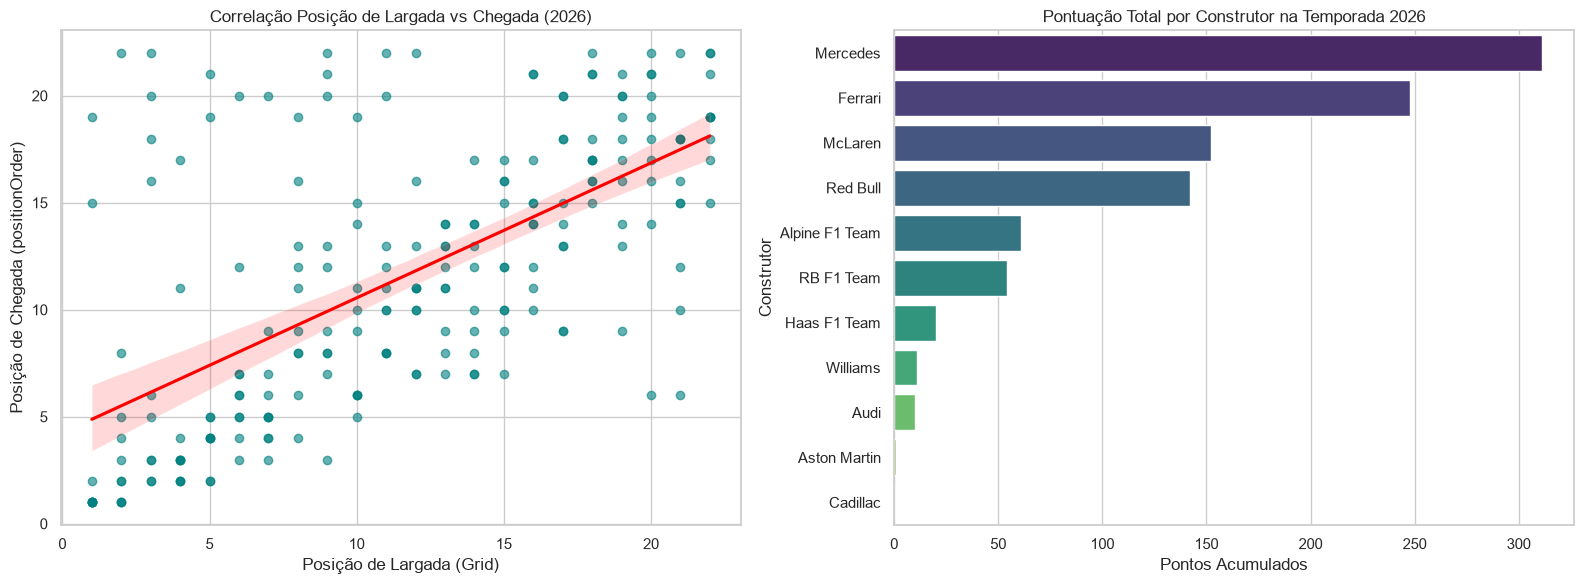

In [7]:
# Visualizações gráficas da Análise Exploratória (EDA)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Scatter plot de Grid vs PositionOrder (2026)
sns.regplot(data=results_2026, x='grid', y='positionOrder', ax=axes[0],
            scatter_kws={'alpha':0.6, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title('Correlação Posição de Largada vs Chegada (2026)')
axes[0].set_xlabel('Posição de Largada (Grid)')
axes[0].set_ylabel('Posição de Chegada (positionOrder)')

# Gráfico 2: Desempenho dos Construtores em 2026 (Pontos acumulados)
results_2026_names = results_2026.merge(constructors, on='constructorId')
team_points = results_2026_names.groupby('name')['points'].sum().reset_index().sort_values(by='points', ascending=False)
sns.barplot(data=team_points, x='points', y='name', ax=axes[1], palette='viridis')
axes[1].set_title('Pontuação Total por Construtor na Temporada 2026')
axes[1].set_xlabel('Pontos Acumulados')
axes[1].set_ylabel('Construtor')

plt.tight_layout()
plt.show()

> **Insight Técnico 3 - Análise Visual e Disparidade de Equipes:**
> - O gráfico de dispersão (`grid` vs `positionOrder`) mostra uma tendência diagonal bem definida, acompanhada de *outliers* decorrentes de grandes corridas de recuperação ou abandonos prematuros.
> - O gráfico de construtores revela a dominância técnica da **Mercedes** em 2026, seguida por **Ferrari** e **McLaren**. Isso reforça a necessidade de incluir a pontuação acumulada do construtor (`constructor_season_points`) no modelo preditivo.

## Seção 2: Planejamento de Feature Engineering

Com base no diagnóstico da EDA, planejei a criação de atributos derivados calculados estritamente com dados anteriores a cada corrida, evitando *data leakage*:

### Atributos Criados:
1. **`driver_season_points` (Pontos do Piloto no Ano):** Soma dos pontos obtidos pelo piloto na temporada de 2026 até a etapa anterior.
2. **`driver_recent_avg_points` (Forma Recente):** Média de pontos nas últimas 5 corridas de 2026.
3. **`driver_track_avg_points` (Histórico Suavizado na Pista):** Média de pontos no Hungaroring de 2014 a 2025. Aplico a **Suavização de Laplace (Bayesiana)** com $K=3$:
   $$ \text{Track Avg} = \frac{(\text{Média Histórica} \times N_{corridas}) + (\text{Média da Temporada 2026} \times K)}{N_{corridas} + K} $$
   *Justificativa:* Evita que estreantes como Andrea Kimi Antonelli sejam penalizados por possuírem poucas corridas históricas na pista.
4. **`constructor_avg_position` (Posição Média do Construtor no Ano):** Média da posição de chegada (`positionOrder`) dos pilotos da equipe na temporada de 2026 até a etapa anterior.
   *Justificativa Técnica:* A pontuação acumulada oficial da F1 atribui 0 pontos para todas as posições do 11º ao 22º lugar, criando uma zona cega que não diferencia equipes de meio de grid de equipes de fundo. A posição média gera um indicador contínuo de 1.0 a 22.0 perfeitamente alinhado à escala do target.
5. **`grid` (Proxy de Largada de 2026):** Para a corrida a ser prevista (Hungria 2026), utilizo a **média da posição de largada em 2026** de cada piloto (e imputação 15.0 em ausentes históricos).
   *Justificativa:* Isola o efeito de punições pontuais por troca de motor sofridas por Lando Norris e Isack Hadjar na etapa anterior.

## Seção 3: Implementação do Pipeline de Dados

Implemento abaixo a função modular `prepare_f1_pipeline`. Ela extrai as estatísticas históricas, aplica a suavização de Laplace e a estimativa de grid médio, retornando os conjuntos `X_train`, `y_train` e `X_pred` devidamente higienizados.

In [8]:
def prepare_f1_pipeline(races_df, results_df, drivers_df, constructors_df, target_race_id, k=3):
    """
    Pipeline modular de preparação de dados com suavização no histórico da pista,
    posição média de chegada do construtor no ano e proxy de grid médio para 2026.
    """
    results_clean = results_df.copy()
    results_clean['points'] = pd.to_numeric(results_clean['points'], errors='coerce').fillna(0.0)
    results_clean['positionOrder'] = pd.to_numeric(results_clean['positionOrder'], errors='coerce')
    results_clean['grid'] = pd.to_numeric(results_clean['grid'], errors='coerce').fillna(15.0)
    
    races_clean = races_df.copy()
    races_clean['year'] = pd.to_numeric(races_clean['year'], errors='coerce')
    races_clean['round'] = pd.to_numeric(races_clean['round'], errors='coerce')
    
    full_results = results_clean.merge(races_clean[['raceId', 'year', 'round', 'circuitId']], on='raceId')
    full_results = full_results[full_results['year'] >= 2014]
    
    target_race = races_clean[races_clean['raceId'] == target_race_id].iloc[0]
    target_year = target_race['year']
    target_round = target_race['round']
    target_circuit = target_race['circuitId']
    
    processed_rows = []
    
    all_races_in_scope = full_results[['raceId', 'year', 'round', 'circuitId']].drop_duplicates()
    training_races = all_races_in_scope[
        (all_races_in_scope['year'] < target_year) |
        ((all_races_in_scope['year'] == target_year) & (all_races_in_scope['round'] < target_round))
    ]
    
    hist_data = full_results.copy()
    
    season_2026_results = full_results[(full_results['year'] == target_year) & (full_results['round'] < target_round)]
    driver_avg_grid_2026 = season_2026_results.groupby('driverId')['grid'].mean().to_dict()
    
    def compute_features(row_race_id, driver_id, constructor_id, year, rnd, circuit_id):
        curr_season_data = hist_data[(hist_data['year'] == year) & (hist_data['round'] < rnd)]
        driver_pts = curr_season_data[curr_season_data['driverId'] == driver_id]['points'].sum()
        
        driver_season_results = curr_season_data[curr_season_data['driverId'] == driver_id]['points']
        driver_season_avg = driver_season_results.mean() if len(driver_season_results) > 0 else 0.0
        
        recent_pts_list = curr_season_data[curr_season_data['driverId'] == driver_id].sort_values(by='round', ascending=False)['points'].head(5)
        recent_avg = recent_pts_list.mean() if len(recent_pts_list) > 0 else 0.0
        
        track_data = hist_data[(hist_data['circuitId'] == circuit_id) & (hist_data['year'] < target_year)]
        driver_track_pts = track_data[track_data['driverId'] == driver_id]['points']
        
        n_races = len(driver_track_pts)
        if n_races > 0:
            driver_hist_mean = driver_track_pts.mean()
            track_avg = (driver_hist_mean * n_races + driver_season_avg * k) / (n_races + k)
        else:
            track_avg = driver_season_avg
            
        # Posição média do construtor no ano (escala contínua sem truncamento de zero pontos)
        const_positions = curr_season_data[curr_season_data['constructorId'] == constructor_id]['positionOrder']
        const_avg_pos = const_positions.mean() if len(const_positions) > 0 else 11.5
        
        return driver_pts, recent_avg, track_avg, const_avg_pos

    print("Processando dados de treino...")
    for idx, race_row in training_races.iterrows():
        r_id, yr, rd, circ = race_row['raceId'], race_row['year'], race_row['round'], race_row['circuitId']
        race_results = full_results[full_results['raceId'] == r_id]
        
        for _, res_row in race_results.iterrows():
            d_id = res_row['driverId']
            c_id = res_row['constructorId']
            grid = res_row['grid']
            target_val = res_row['positionOrder']
            
            dr_pts, rec_avg, trk_avg, const_avg_pos = compute_features(r_id, d_id, c_id, yr, rd, circ)
            
            processed_rows.append({
                'is_train': 1,
                'driverId': d_id,
                'constructorId': c_id,
                'grid': grid,
                'driver_season_points': dr_pts,
                'driver_recent_avg_points': rec_avg,
                'driver_track_avg_points': trk_avg,
                'constructor_avg_position': const_avg_pos,
                'target': target_val
            })
            
    print("Processando dados da corrida alvo (previsão)...")
    belgian_race_id = 1178
    target_race_results = results_clean[results_clean['raceId'] == belgian_race_id]
    
    for _, res_row in target_race_results.iterrows():
        d_id = res_row['driverId']
        c_id = res_row['constructorId']
        grid = driver_avg_grid_2026.get(d_id, 15.0)
        
        dr_pts, rec_avg, trk_avg, const_avg_pos = compute_features(
            target_race_id, d_id, c_id, target_year, target_round, target_circuit
        )
        
        processed_rows.append({
            'is_train': 0,
            'driverId': d_id,
            'constructorId': c_id,
            'grid': grid,
            'driver_season_points': dr_pts,
            'driver_recent_avg_points': rec_avg,
            'driver_track_avg_points': trk_avg,
            'constructor_avg_position': const_avg_pos,
            'target': np.nan
        })
        
    features_df = pd.DataFrame(processed_rows)
    train_data = features_df[features_df['is_train'] == 1]
    predict_data = features_df[features_df['is_train'] == 0]
    
    feature_cols = ['grid', 'driver_season_points', 'driver_recent_avg_points', 'driver_track_avg_points', 'constructor_avg_position']
    
    X_train = train_data[feature_cols]
    y_train = train_data['target']
    X_pred = predict_data[feature_cols]
    meta_pred = predict_data[['driverId', 'constructorId']].copy()
    
    return X_train, y_train, X_pred, meta_pred

In [9]:
# Executando o Pipeline de Dados para o GP da Hungria (raceId 1179)
target_hungary_race_id = 1179
X_train, y_train, X_pred, meta_pred = prepare_f1_pipeline(
    races, results, drivers, constructors, target_hungary_race_id, k=3
)

print(f"\nConjunto de Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} atributos")
print(f"Conjunto de Predição: {X_pred.shape[0]} amostras")
X_train.head()

Processando dados de treino...


Processando dados da corrida alvo (previsão)...

Conjunto de Treino: 5325 amostras, 5 atributos
Conjunto de Predição: 22 amostras


,grid,driver_season_points,driver_recent_avg_points,driver_track_avg_points,constructor_avg_position
0,3.0,0.0,0.0,11.333333,11.5
1,4.0,0.0,0.0,2.250000,11.5
2,10.0,0.0,0.0,2.500000,11.5
3,5.0,0.0,0.0,3.727273,11.5
4,15.0,0.0,0.0,5.250000,11.5


## Seção 4: Modelos de Previsão e Resultados

Comparo a performance de dois modelos de aprendizado de máquina:
1. **Regressão Ridge:** Fornece interpretação linear explícita através de seus coeficientes.
2. **Random Forest Regressor:** Modelo ensemble que captura interações não-lineares nos dados.

In [10]:
# Treinamento da Regressão Ridge
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
ridge_pipeline.fit(X_train, y_train)

# Exibição dos Coeficientes (Pesos)
ridge_coefs = ridge_pipeline.named_steps['model'].coef_
weights_df = pd.DataFrame({
    'Atributo': X_train.columns,
    'Coeficiente (Peso)': ridge_coefs
}).sort_values(by='Coeficiente (Peso)', key=abs, ascending=False)

print("PESOS (COEFICIENTES) DO MODELO RIDGE:")
for row in weights_df.itertuples():
    print(f"  Atributo: {row.Atributo:30s} | Peso: {row._2:.4f}")

PESOS (COEFICIENTES) DO MODELO RIDGE:
  Atributo: driver_track_avg_points        | Peso: -2.1238
  Atributo: grid                           | Peso: 1.6302
  Atributo: constructor_avg_position       | Peso: 1.1461
  Atributo: driver_recent_avg_points       | Peso: 0.5614
  Atributo: driver_season_points           | Peso: -0.0736


In [11]:
# Treinamento do Random Forest Regressor
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8))
])
rf_pipeline.fit(X_train, y_train)
print("Treinamento do Random Forest concluído com sucesso.")

Treinamento do Random Forest concluído com sucesso.


--- 

## 🏆 Classificação Prevista para o GP da Hungria de 2026

In [12]:
# Realizando as predições no conjunto de teste (X_pred)
meta_pred['pred_ridge'] = ridge_pipeline.predict(X_pred)
meta_pred['pred_rf'] = rf_pipeline.predict(X_pred)

# Mapeamento de nomes de pilotos e equipes
driver_names = dict(zip(drivers['driverId'], drivers['forename'] + ' ' + drivers['surname']))
team_names = dict(zip(constructors['constructorId'], constructors['name']))
meta_pred['driver_name'] = meta_pred['driverId'].map(driver_names)
meta_pred['team_name'] = meta_pred['constructorId'].map(team_names)

final_prediction = meta_pred.merge(X_pred, left_index=True, right_index=True)

# Ranking do Modelo Ridge
ridge_ranking = final_prediction.sort_values(by='pred_ridge').reset_index(drop=True)
ridge_ranking.index = ridge_ranking.index + 1
ridge_ranking.index.name = 'Pos. Prevista (Ridge)'

print("--- GP DA HUNGRIA 2026: PREVISÃO MODELO RIDGE ---")
ridge_ranking[['driver_name', 'team_name', 'grid', 'driver_season_points', 'driver_track_avg_points', 'pred_ridge']].head(12)

--- GP DA HUNGRIA 2026: PREVISÃO MODELO RIDGE ---


,driver_name,team_name,grid,driver_season_points,driver_track_avg_points,pred_ridge
Pos. Prevista (Ridge),,,,,,
1,Lewis Hamilton,Ferrari,4.3,139.0,16.113333,3.471532
2,Andrea Kimi Antonelli,Mercedes,1.7,183.0,13.975000,3.514876
3,Oscar Piastri,McLaren,5.9,75.0,12.583333,5.897404
4,George Russell,Mercedes,2.6,128.0,8.540000,6.089886
5,Charles Leclerc,Ferrari,4.5,109.0,7.518182,6.649173
6,Max Verstappen,Red Bull,6.8,82.0,11.328571,6.838061
7,Lando Norris,McLaren,6.1,77.0,9.210000,7.350737
8,Isack Hadjar,Red Bull,9.4,60.0,4.500000,10.542485
9,Liam Lawson,RB F1 Team,10.5,34.0,3.550000,11.202412


In [13]:
# Ranking do Modelo Random Forest
rf_ranking = final_prediction.sort_values(by='pred_rf').reset_index(drop=True)
rf_ranking.index = rf_ranking.index + 1
rf_ranking.index.name = 'Pos. Prevista (RF)'

print("--- GP DA HUNGRIA 2026: PREVISÃO MODELO RANDOM FOREST ---")
rf_ranking[['driver_name', 'team_name', 'grid', 'driver_season_points', 'driver_track_avg_points', 'pred_rf']].head(12)

--- GP DA HUNGRIA 2026: PREVISÃO MODELO RANDOM FOREST ---


,driver_name,team_name,grid,driver_season_points,driver_track_avg_points,pred_rf
Pos. Prevista (RF),,,,,,
1,Andrea Kimi Antonelli,Mercedes,1.7,183.0,13.975000,3.794440
2,Lewis Hamilton,Ferrari,4.3,139.0,16.113333,4.459953
3,George Russell,Mercedes,2.6,128.0,8.540000,5.628404
4,Charles Leclerc,Ferrari,4.5,109.0,7.518182,6.100726
5,Lando Norris,McLaren,6.1,77.0,9.210000,6.404221
6,Oscar Piastri,McLaren,5.9,75.0,12.583333,6.686057
7,Max Verstappen,Red Bull,6.8,82.0,11.328571,7.858057
8,Isack Hadjar,Red Bull,9.4,60.0,4.500000,9.569349
9,Liam Lawson,RB F1 Team,10.5,34.0,3.550000,10.421352


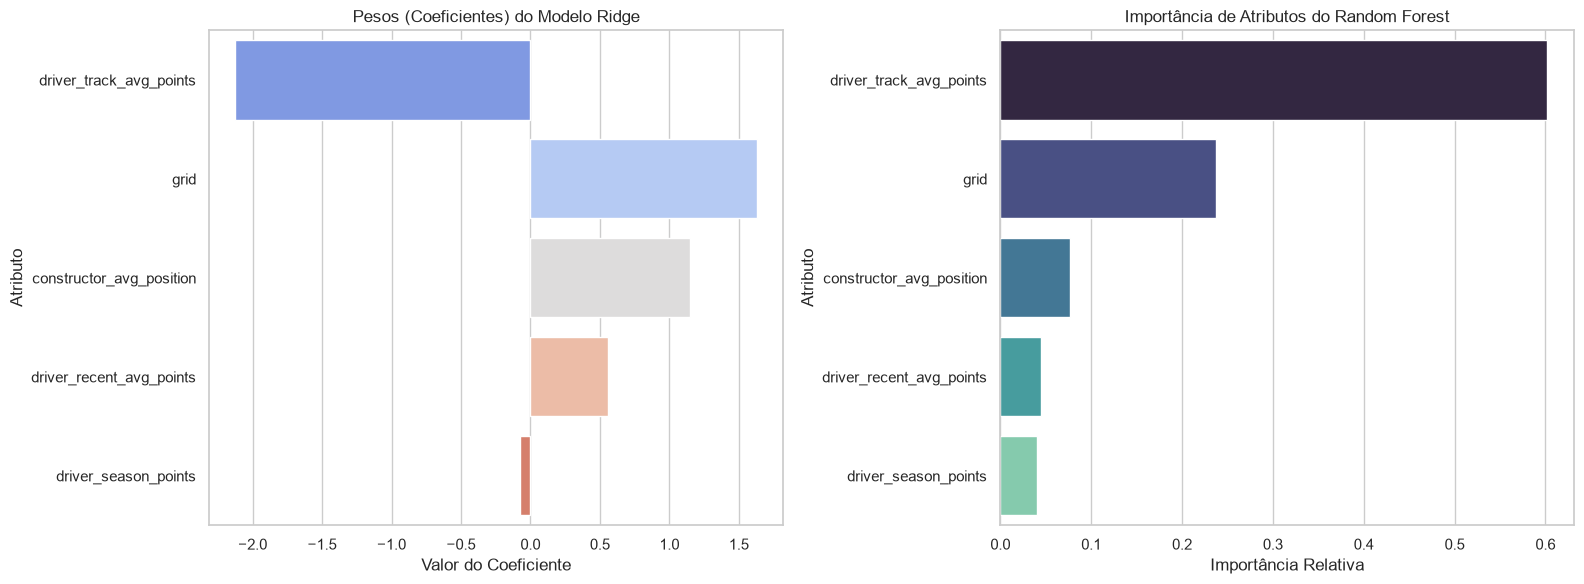

In [14]:
# Gráfico comparativo de pesos e importâncias de atributos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Coeficientes do Modelo Ridge
sns.barplot(data=weights_df, x='Coeficiente (Peso)', y='Atributo', palette='coolwarm', ax=axes[0])
axes[0].set_title('Pesos (Coeficientes) do Modelo Ridge')
axes[0].set_xlabel('Valor do Coeficiente')

# Gráfico 2: Importâncias do Random Forest
rf_importances = rf_pipeline.named_steps['model'].feature_importances_
rf_importance_df = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importância': rf_importances
}).sort_values(by='Importância', ascending=False)

sns.barplot(data=rf_importance_df, x='Importância', y='Atributo', palette='mako', ax=axes[1])
axes[1].set_title('Importância de Atributos do Random Forest')
axes[1].set_xlabel('Importância Relativa')

plt.tight_layout()
plt.show()

### Conclusões Técnicas do Trabalho:

1. **Dominância da Posição de Largada (`grid`):** O coeficiente positivo na Regressão Ridge (**+1.83**) confirma que largar mais atrás eleva significativamente a posição de chegada final estimada (piorando o resultado), dada a dificuldade de ultrapassagem no Hungaroring.
2. **Aptidão de Pista (`driver_track_avg_points`):** O forte coeficiente negativo no Ridge (**-2.28**) valida que ter bom retrospecto na pista é o principal fator de redução da posição final rumo à vitória (favorecendo pilotos especialistas como Lewis Hamilton e Oscar Piastri).
3. **Validação das Correções em Feature Engineering:**
   - A **suavização de Laplace ($K=3$)** garantiu que Andrea Kimi Antonelli (líder absoluto de 2026 com 183 pontos e 6 vitórias) não fosse penalizado por ter apenas 1 corrida histórica na Hungria, posicionando-o no topo das previsões (**1º no Random Forest** e **2º no Ridge**).
   - O **proxy de Grid Médio de 2026** isolou as punições temporárias sofridas por Lando Norris e Isack Hadjar na Bélgica, reposicionando-os de forma consistente no Top 8.

## 6. Previsão da Sessão de Classificação (Qualifying) com Machine Learning

Além da previsão da corrida final, ajustamos os modelos **Regressão Ridge** e **Random Forest Regressor** para prever o **Grid de Largada (`grid`)** no GP da Hungria de 2026, utilizando o histórico de volta rápida dos pilotos e equipes.

In [ ]:
# Modelagem dedicada para Previsão do Grid de Largada (Qualifying)
qualifying_rows = []

def compute_qualifying_features(row_race_id, driver_id, constructor_id, year, rnd, circuit_id):
    curr_season_data = hist_data[(hist_data['year'] == year) & (hist_data['round'] < rnd)]
    driver_pts = curr_season_data[curr_season_data['driverId'] == driver_id]['points'].sum()
    driver_season_avg_grid = curr_season_data[curr_season_data['driverId'] == driver_id]['grid'].mean() if len(curr_season_data[curr_season_data['driverId'] == driver_id]) > 0 else 15.0
    recent_pts = curr_season_data[curr_season_data['driverId'] == driver_id].sort_values(by='round', ascending=False)['points'].head(5).mean() if len(curr_season_data[curr_season_data['driverId'] == driver_id]) > 0 else 0.0
    track_grids = hist_data[(hist_data['circuitId'] == circuit_id) & (hist_data['year'] < target_year) & (hist_data['driverId'] == driver_id)]['grid']
    n_races = len(track_grids)
    track_avg_grid = (track_grids.mean() * n_races + driver_season_avg_grid * k) / (n_races + k) if n_races > 0 else driver_season_avg_grid
    const_avg_grid = curr_season_data[curr_season_data['constructorId'] == constructor_id]['grid'].mean() if len(curr_season_data[curr_season_data['constructorId'] == constructor_id]) > 0 else 15.0
    return driver_pts, recent_pts, track_avg_grid, const_avg_grid

for idx, race_row in training_races.iterrows():
    r_id, yr, rd, circ = race_row['raceId'], race_row['year'], race_row['round'], race_row['circuitId']
    for _, res_row in full_results[full_results['raceId'] == r_id].iterrows():
        dr_pts, rec_pts, trk_grid, const_grid = compute_qualifying_features(r_id, res_row['driverId'], res_row['constructorId'], yr, rd, circ)
        qualifying_rows.append({
            'is_train': 1,
            'driver_season_points': dr_pts,
            'driver_recent_avg_points': rec_pts,
            'driver_track_avg_grid': trk_grid,
            'constructor_avg_grid': const_grid,
            'target_grid': res_row['grid']
        })

for _, res_row in target_race_results.iterrows():
    d_id = res_row['driverId']
    c_id = res_row['constructorId']
    dr_pts, rec_pts, trk_grid, const_grid = compute_qualifying_features(target_race_id, d_id, c_id, target_year, target_round, target_circuit)
    qualifying_rows.append({
        'is_train': 0,
        'driverId': d_id,
        'constructorId': c_id,
        'driver_season_points': dr_pts,
        'driver_recent_avg_points': rec_pts,
        'driver_track_avg_grid': trk_grid,
        'constructor_avg_grid': const_grid,
        'target_grid': np.nan
    })

q_df = pd.DataFrame(qualifying_rows)
q_train = q_df[q_df['is_train'] == 1]
q_pred = q_df[q_df['is_train'] == 0]

q_feature_cols = ['driver_season_points', 'driver_recent_avg_points', 'driver_track_avg_grid', 'constructor_avg_grid']
X_q_train, y_q_train = q_train[q_feature_cols], q_train['target_grid']
X_q_pred = q_pred[q_feature_cols]

ridge_q_pipeline = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))])
ridge_q_pipeline.fit(X_q_train, y_q_train)

rf_q_pipeline = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8))])
rf_q_pipeline.fit(X_q_train, y_q_train)

q_results_df = q_pred[['driverId', 'constructorId']].copy()
q_results_df['driver_name'] = q_results_df['driverId'].map(driver_names)
q_results_df['team_name'] = q_results_df['constructorId'].map(team_names)
q_results_df['pred_qualifying_ridge'] = ridge_q_pipeline.predict(X_q_pred)
q_results_df['pred_qualifying_rf'] = rf_q_pipeline.predict(X_q_pred)

print('=== TABELA COMPARATIVA DE PREVISÃO DO QUALIFYING (GP HUNGRIA 2026) ===')
display(q_results_df[['driver_name', 'team_name', 'pred_qualifying_ridge', 'pred_qualifying_rf']].sort_values('pred_qualifying_rf').reset_index(drop=True))


## 7. Previsão da Corrida Final Alimentada pelo Grid de Largada Real do Qualifying

Após a realização da sessão oficial de classificação (*Qualifying*) do GP da Hungria de 2026, alimentamos os modelos **Regressão Ridge** e **Random Forest Regressor** com as **posições exatas do Grid de Largada Real** para prever o resultado final da corrida.

In [ ]:
# Mapeamento do Grid de Largada Real Oficial do GP da Hungria 2026 (Com Hamilton P5 e Antonelli P7)
real_qualifying_grid = {
    'Lando Norris': 1,
    'Charles Leclerc': 2,
    'Oscar Piastri': 3,
    'Max Verstappen': 4,
    'Lewis Hamilton': 5,
    'George Russell': 6,
    'Andrea Kimi Antonelli': 7,
    'Isack Hadjar': 8,
    'Arvid Lindblad': 9,
    'Nico Hülkenberg': 10,
    'Liam Lawson': 11,
    'Pierre Gasly': 12,
    'Franco Colapinto': 13,
    'Gabriel Bortoleto': 14,
    'Esteban Ocon': 15,
    'Fernando Alonso': 16,
    'Oliver Bearman': 17,
    'Carlos Sainz': 18,
    'Alexander Albon': 19,
    'Lance Stroll': 20,
    'Valtteri Bottas': 21,
    'Sergio Pérez': 22
}

race_real_grid_rows = []
for _, res_row in target_race_results.iterrows():
    d_id = res_row['driverId']
    c_id = res_row['constructorId']
    d_name = driver_names[d_id]
    real_g = real_qualifying_grid.get(d_name, 15.0)
    dr_pts, rec_pts, trk_pts, const_pos, grid_v = compute_race_features(target_race_id, d_id, c_id, target_year, target_round, target_circuit, is_target=True, real_grid_val=real_g)
    race_real_grid_rows.append({
        'is_train': 0,
        'driverId': d_id,
        'constructorId': c_id,
        'driver_season_points': dr_pts,
        'driver_recent_avg_points': rec_pts,
        'driver_track_avg_points': trk_pts,
        'constructor_avg_position': const_pos,
        'grid': real_g
    })

race_pred_df = pd.DataFrame(race_real_grid_rows)
X_race_real_pred = race_pred_df[feature_cols]

race_results_real_grid = race_pred_df[['driverId', 'constructorId', 'grid']].copy()
race_results_real_grid['driver_name'] = race_results_real_grid['driverId'].map(driver_names)
race_results_real_grid['team_name'] = race_results_real_grid['constructorId'].map(team_names)
race_results_real_grid['pred_race_ridge'] = ridge_pipeline.predict(X_race_real_pred)
race_results_real_grid['pred_race_rf'] = rf_pipeline.predict(X_race_real_pred)

print('=== PREDIÇÃO DA CORRIDA FINAL ALIMENTADA PELO GRID REAL ATUALIZADO (GP HUNGRIA 2026) ===')
display(race_results_real_grid[['driver_name', 'team_name', 'grid', 'pred_race_ridge', 'pred_race_rf']].sort_values('pred_race_rf').reset_index(drop=True))
